## Baseline Logistic Regression

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [9]:
df = pd.read_csv("../data/processed/processed_imdb.csv")
df.head()

,review,sentiment,label,clean_review,processed_review,word_count,processed_word_count
0,One of the other reviewers has mentioned that ...,positive,1,one of the other reviewers has mentioned that ...,reviewer mention watch oz episode ll hook righ...,307,154
1,A wonderful little production. <br /><br />The...,positive,1,a wonderful little production the filming tech...,wonderful little production filming technique ...,162,80
2,I thought this was a wonderful way to spend ti...,positive,1,i thought this was a wonderful way to spend ti...,think wonderful way spend time hot summer week...,166,78
3,Basically there's a family where a little boy ...,negative,0,basically there s a family where a little boy ...,basically s family little boy jake think s zom...,138,60
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1,petter mattei s love in the time of money is a...,petter mattei s love time money visually stunn...,230,115


In [10]:
X =df["processed_review"]
y=df["label"]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

In [12]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1765,
    random_state=42,
    stratify=y_train
)

In [13]:
print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 34998
Validation size: 7502
Test size: 7500


In [14]:
tfidf =TfidfVectorizer(
    max_features = 10000,
    ngram_range = (1,2),
    sublinear_tf=True
)

In [17]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

In [18]:
print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_val_tfidf shape:", X_val_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (34998, 10000)
X_val_tfidf shape: (7502, 10000)
X_test_tfidf shape: (7500, 10000)


In [21]:
x0 = X_train_tfidf[0]
print(x0)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 62 stored elements and shape (1, 10000)>
  Coords	Values
  (0, 5222)	0.06320161058922195
  (0, 550)	0.11646812721076667
  (0, 6439)	0.07320674827164245
  (0, 5719)	0.07662889626831615
  (0, 6690)	0.06098373669859115
  (0, 9333)	0.09377817194779824
  (0, 988)	0.16083121314916252
  (0, 7781)	0.076567778505427
  (0, 6839)	0.13630919634083918
  (0, 2165)	0.16272886644051235
  (0, 8938)	0.10396660427589632
  (0, 6149)	0.12889417726246297
  (0, 97)	0.06594360545358746
  (0, 477)	0.13552778863013457
  (0, 2958)	0.11062113583985525
  (0, 4721)	0.08527759736619828
  (0, 5595)	0.13527916785582017
  (0, 8777)	0.1672730155974947
  (0, 5086)	0.12893119490117583
  (0, 7361)	0.13073251982262
  (0, 7195)	0.10035737011616643
  (0, 3227)	0.062449974281286125
  (0, 6809)	0.14516872763654887
  (0, 9638)	0.19183168185572708
  (0, 1182)	0.1613276190020216
  :	:
  (0, 3525)	0.06141331293976234
  (0, 7405)	0.0958187767990431
  (0, 3588)	0.127933044

In [22]:
lr_model = LogisticRegression(
    max_iter = 1000,
    random_state = 42
)

In [23]:
lr_model.fit(X_train_tfidf,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [24]:
y_val_pred =lr_model.predict(X_val_tfidf)

In [25]:
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)

print("Validation Metrics")
print(f"Accuracy : {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1 Score : {val_f1:.4f}")

Validation Metrics
Accuracy : 0.8914
Precision: 0.8785
Recall   : 0.9083
F1 Score : 0.8932


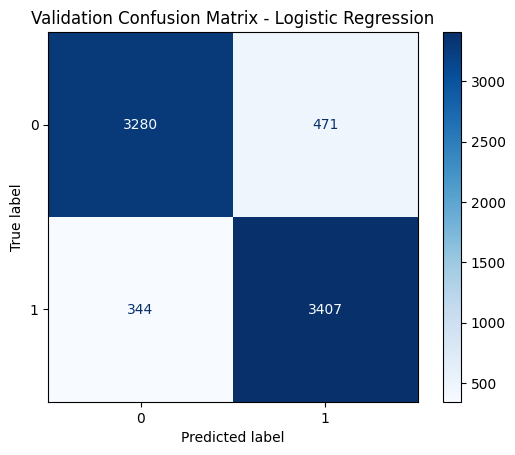

In [26]:
val_cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=val_cm)
disp.plot(cmap="Blues")
plt.title("Validation Confusion Matrix - Logistic Regression")
plt.show()

In [27]:
y_test_pred = lr_model.predict(X_test_tfidf)

In [28]:
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Test Metrics")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")

Test Metrics
Accuracy : 0.8968
Precision: 0.8873
Recall   : 0.9091
F1 Score : 0.8981


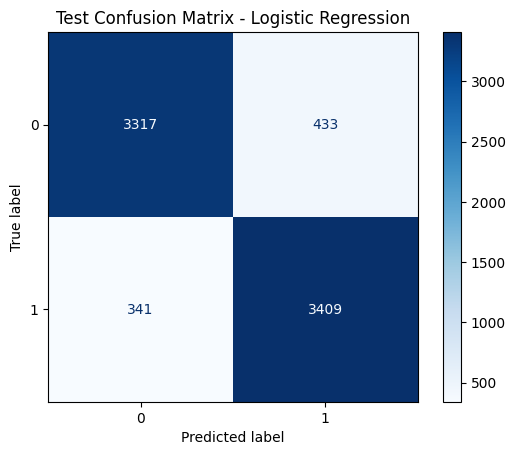

In [29]:
test_cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=test_cm)
disp.plot(cmap="Blues")
plt.title("Test Confusion Matrix - Logistic Regression")
plt.show()

In [30]:
feature_names = np.array(tfidf.get_feature_names_out())
coefficients = lr_model.coef_[0]

In [31]:
top_positive_idx = np.argsort(coefficients)[-20:]
top_positive_words = feature_names[top_positive_idx]
top_positive_scores = coefficients[top_positive_idx]

for word, score in zip(top_positive_words, top_positive_scores):
    print(f"{word}: {score:.4f}")

entertaining: 3.2735
highly recommend: 3.3171
fantastic: 3.5186
enjoyable: 3.5782
funniest: 3.6613
today: 3.8827
brilliant: 3.9345
superb: 3.9675
definitely: 3.9928
enjoy: 4.0658
favorite: 4.1600
fun: 4.3349
hilarious: 4.3474
love: 4.3512
wonderful: 4.6582
amazing: 4.7809
perfect: 5.0308
good: 5.1356
excellent: 6.5191
great: 7.2130


In [33]:
top_negative_idx = np.argsort(coefficients)[:20]
top_negative_words = feature_names[top_negative_idx]
top_negative_scores = coefficients[top_negative_idx]

for word, score in zip(top_negative_words, top_negative_scores):
    print(f"{word}: {score:.4f}")

bad: -10.7328
waste: -7.6388
awful: -7.4071
boring: -5.7777
poor: -5.6522
terrible: -5.5051
fail: -4.9602
dull: -4.7827
poorly: -4.7159
suppose: -4.6094
horrible: -4.5310
stupid: -4.4556
lack: -4.4292
disappointment: -4.3757
instead: -4.3519
lame: -4.2336
disappointed: -4.2267
not worth: -4.1802
save: -4.0221
no: -4.0193


In [34]:
baseline_results = pd.DataFrame([
    {
        "Model": "TF-IDF + Logistic Regression",
        "Validation Accuracy": val_accuracy,
        "Validation Precision": val_precision,
        "Validation Recall": val_recall,
        "Validation F1": val_f1,
        "Test Accuracy": test_accuracy,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1": test_f1
    }
])

baseline_results

,Model,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,TF-IDF + Logistic Regression,0.891362,0.878546,0.908291,0.893171,0.8968,0.887298,0.909067,0.898051


In [35]:
baseline_results.to_csv("../results/baseline_results.csv", index=False)
print("Baseline results saved.")

Baseline results saved.
